In [ ]:
import pandas as pd
import requests

request_url = "https://cyclobs.ifremer.fr/app/api/getData?cyclone_name=IDAI"

df = pd.read_csv(request_url)

print(df.head())

Querying CyclObs API...
File rcm1-sclna-owi-cm-20260326t215721-20260326t215831-00003-xxxxx_ll_gd.nc already exists. Skipping download.
Processing NetCDF...
--- DIMENSIONS ---
FrozenMappingWarningOnValuesAccess({'time': 1, 'lat': 538, 'lon': 488})

--- COORDINATES ---
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-03-26T21:57:56
  * lat      (lat) float64 4kB -19.41 -19.42 -19.43 ... -24.39 -24.4 -24.41
  * lon      (lon) float64 4kB 111.7 111.7 111.7 111.7 ... 116.2 116.2 116.2

--- DATA VARIABLES ---
Data variables:
    wind_speed                     (time, lat, lon) float32 1MB dask.array<chunksize=(1, 538, 488), meta=np.ndarray>
    wind_from_direction            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 538, 488), meta=np.ndarray>
    mask_flag                      (time, lat, lon) float32 1MB dask.array<chunksize=(1, 538, 488), meta=np.ndarray>
    heterogeneity_mask             (time, lat, lon) float32 1MB dask.array<chunksize=(1, 538, 488), meta=np.ndarray>


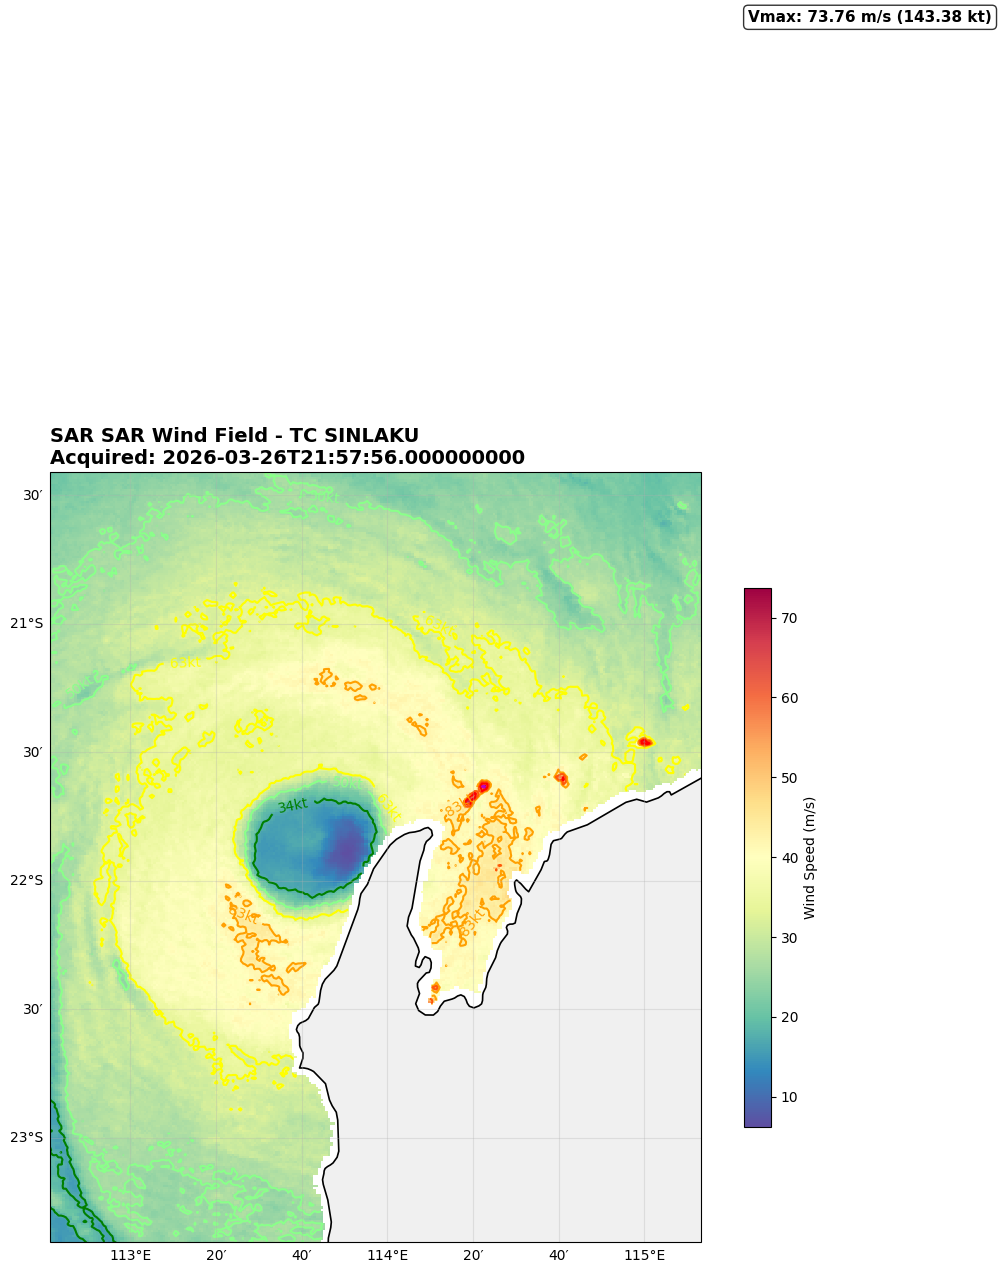

In [4]:
import pandas as pd
import requests
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
import io  # Standard library for handling string streams

# --- 1. OPTIMIZED API QUERY & SESSION SETUP ---
session = requests.Session()
api_url = "https://cyclobs.ifremer.fr/app/api/getData"

# Query for the latest system
query_params = {
    "sid": "sh272026", 
    "instrument": "C-Band_SAR",
    "include_cols": "data_url,acquisition_start_time,cyclone_name"
}

print("Querying CyclObs API...")
r = session.get(api_url, params=query_params)

# FIX: Use io.StringIO instead of pd.compat
df = pd.read_csv(io.StringIO(r.text))

if df.empty:
    print(f"Server Response: {r.text}")
    raise ValueError("No products found. Check SID or server status.")

# Sort and get latest
latest_product = df.sort_values('acquisition_start_time').iloc[-4]
download_url = latest_product['data_url']
filename = os.path.basename(download_url)

# --- 2. DOWNLOAD WITH TQDM ---
if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    response = session.get(download_url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    chunk_size = 1024 * 1024 

    with open(filename, "wb") as f, tqdm(
        desc=filename,
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=chunk_size):
            size = f.write(data)
            bar.update(size)
else:
    print(f"File {filename} already exists. Skipping download.")

# --- 3. ROBUST VISUALIZATION ---
print("Processing NetCDF...")
ds = xr.open_dataset(filename, chunks={})

# Print the structural metadata
print("--- DIMENSIONS ---")
print(ds.dims)

print("\n--- COORDINATES ---")
print(ds.coords)

print("\n--- DATA VARIABLES ---")
print(ds.data_vars)

print("\n--- GLOBAL ATTRIBUTES ---")
for attr in ds.attrs:
    print(f"{attr}: {ds.attrs[attr]}")

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP & DATA EXTRACTION
lons = ds.lon.squeeze().values
lats = ds.lat.squeeze().values
winds_ms = ds.wind_speed.squeeze().values #Convert to 1min
winds_kt = winds_ms * 1.94384

# Extract Metadata
storm_name = ds.attrs.get('Storm name', 'SINLAKU')
# Clean up sensor name from the filename attribute
sensor_info = ds.attrs.get('Source satellite file', 'SAR').split('-')[0].upper()
# Extract true maximum from the actual wind speed pixels
true_max_ms = np.nanmax(winds_ms)
true_max_kt = true_max_ms * 1.94384

# 2. CREATE FIGURE
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)

# 3. PLOT WIND FIELD
mesh = ax.pcolormesh(
    lons, lats, winds_ms,
    transform=ccrs.PlateCarree(),
    cmap='Spectral_r',
    shading='auto'
)

# 4. ADD ISOLINES
levels_kt = [34, 50, 64, 83, 96, 113, 137]
#Hex code for light green
colors_kt = ['g', '#8AFF8A', '#ffff00', '#ffa001', '#ff5908', 'r', 'm']
levels_ms = [val / 1.94384 for val in levels_kt]

# We filter levels to ensure they actually exist in the data to avoid empty contour errors
existing_levels = [l for l in levels_ms if l < np.nanmax(winds_ms)]

if existing_levels:
    contours = ax.contour(
        lons, lats, winds_ms, 
        levels=existing_levels, 
        colors=colors_kt, 
        linewidths=1.5,
        transform=ccrs.PlateCarree()
    )
    
    # clabel fix: removed 'fontweight'
    fmt = {ms: f'{int(ms * 1.94384)}kt' for ms in existing_levels}
    plt.clabel(contours, fmt=fmt, inline=True, fontsize=10)

# 5. DISPLAY MAX WIND ANNOTATION
# Ensure we get scalar floats for the text placement
try:
    c_lon = ds.lon_storm_center.values.item()
    c_lat = ds.lat_storm_center.values.item()
except AttributeError:
    # Fallback if the variable name differs slightly
    c_lon, c_lat = np.nanmean(lons), np.nanmean(lats)

ax.text(
    c_lon + 1.45, c_lat + 3.25, 
    f"Vmax: {true_max_ms:.2f} m/s ({true_max_kt:.2f} kt)",
    transform=ccrs.PlateCarree(),
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'),
    fontsize=11, fontweight='bold', zorder=5
)

# 6. FORMATTING & TITLE
ax.set_extent([np.nanmin(lons)+1, np.nanmax(lons)-1, 
               np.nanmin(lats)+1, np.nanmax(lats)-1], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
gl.top_labels = gl.right_labels = False

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.04, shrink=0.7)
cbar.set_label('Wind Speed (m/s)')

plt.title(f"{sensor_info} SAR Wind Field - TC {storm_name}\nAcquired: {ds.time.values[0]}", 
          loc='left', fontsize=14, fontweight='bold')

plt.show()


In [9]:
request_url = "https://cyclobs.ifremer.fr/app/api/getData?sid=sh272026&include_cols=all"
df = pd.read_csv(request_url)

print(df.head())

                                            data_url  \
0  https://cyclobs.ifremer.fr/static/sarwing_data...   
1  https://cyclobs.ifremer.fr/static/sarwing_data...   
2  https://cyclobs.ifremer.fr/static/sarwing_data...   
3  https://cyclobs.ifremer.fr/static/sarwing_data...   
4  https://cyclobs.ifremer.fr/static/sarwing_data...   

                    mission mission_short                       instrument  \
0  RADARSAT Constellation 1          RCM1  C-Band Synthetic Aperture Radar   
1  RADARSAT Constellation 1          RCM1  C-Band Synthetic Aperture Radar   
2  RADARSAT Constellation 1          RCM1  C-Band Synthetic Aperture Radar   
3  RADARSAT Constellation 1          RCM1  C-Band Synthetic Aperture Radar   
4  RADARSAT Constellation 1          RCM1  C-Band Synthetic Aperture Radar   

  instrument_short acquisition_start_time  \
0       C-Band SAR    2026-03-20 08:55:12   
1       C-Band SAR    2026-03-21 09:03:22   
2       C-Band SAR    2026-03-24 21:39:54   
3       C-Band

In [3]:
print(ds.mask_flag)

<xarray.DataArray 'mask_flag' (time: 1, lat: 538, lon: 488)> Size: 1MB
dask.array<open_dataset-mask_flag, shape=(1, 538, 488), dtype=float32, chunksize=(1, 538, 488), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-03-26T21:57:56
  * lat      (lat) float64 4kB -19.41 -19.42 -19.43 ... -24.39 -24.4 -24.41
  * lon      (lon) float64 4kB 111.7 111.7 111.7 111.7 ... 116.2 116.2 116.2
Attributes:
    long_name:      Mask of data
    description:    Mask of data
    valid_range:    [0 3]
    flag_values:    [0 1 2 3]
    flag_meanings:  valid land ice no_valid
